In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv("kaggle_data/train.csv", index_col = 'PassengerId')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


## Анализ данных

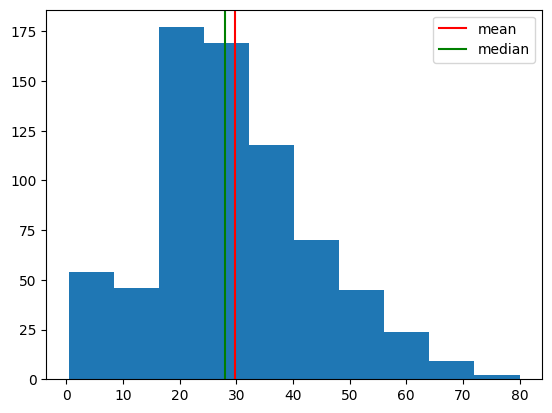

In [11]:
df['Embarked'].mode()
mean = np.mean(df['Age'].dropna().values)
median = np.quantile(df['Age'].dropna().values, q=0.5)
plt.hist(df['Age'])
plt.axvline(x = mean, color = 'red', label='mean')
plt.axvline(x = median, color = 'green', label = 'median')
plt.legend()

In [12]:
df.dropna(inplace=True)

In [13]:
df.isna().sum(axis=0)

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

In [14]:
df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
pd.crosstab(df['Title'], df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,1
Countess,1,0
Dr,1,2
Lady,1,0
Major,0,2
Master,0,7
Miss,44,0
Mlle,2,0


In [15]:
df['Title'] = df['Title'].replace(['Lady', 'Capt', 'Col', 'Countess', 'Dr', 'Major', 'Don', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

df[['Title', 'Survived']].groupby(['Title'], as_index = False).mean()

,Title,Survived
0,Master,1.000000
1,Miss,0.934783
2,Mr,0.370370
3,Mrs,0.923077
4,Rare,0.700000


In [16]:
df.drop(columns = ['Cabin', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
2,1,1,female,38.0,1,0,71.2833,C,Mrs
4,1,1,female,35.0,1,0,53.1000,S,Mrs
7,0,1,male,54.0,0,0,51.8625,S,Mr
11,1,3,female,4.0,1,1,16.7000,S,Miss
12,1,1,female,58.0,0,0,26.5500,S,Miss


In [17]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title'],
      dtype='object')

In [18]:
categorial_columns = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Title']
categorial_features = df[categorial_columns]
categorial_features

,Pclass,Sex,SibSp,Parch,Embarked,Title
PassengerId,,,,,,
2,1,female,1,0,C,Mrs
4,1,female,1,0,S,Mrs
7,1,male,0,0,S,Mr
11,3,female,1,1,S,Miss
12,1,female,0,0,S,Miss
...,...,...,...,...,...,...
872,1,female,1,1,S,Mrs
873,1,male,0,0,S,Mr
880,1,female,0,1,C,Mrs


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 2 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  183 non-null    int64  
 1   Pclass    183 non-null    int64  
 2   Sex       183 non-null    object 
 3   Age       183 non-null    float64
 4   SibSp     183 non-null    int64  
 5   Parch     183 non-null    int64  
 6   Fare      183 non-null    float64
 7   Embarked  183 non-null    object 
 8   Title     183 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 14.3+ KB


In [20]:
unprocessed_cat_features = categorial_features.select_dtypes(include=[object]).columns.to_list()
unprocessed_cat_features

['Sex', 'Embarked', 'Title']

In [21]:
df[unprocessed_cat_features]

,Sex,Embarked,Title
PassengerId,,,
2,female,C,Mrs
4,female,S,Mrs
7,male,S,Mr
11,female,S,Miss
12,female,S,Miss
...,...,...,...
872,female,S,Mrs
873,male,S,Mr
880,female,C,Mrs


**Как переводить категориальные признаки в числовые?**
1. _One-hot encoding_
2. _Label encoding_

1. Используем метод Pandas под названием get_dummies

In [22]:
one_hot = pd.get_dummies(df['Title'])
df_one_hot = pd.concat([df, one_hot], axis = 1)
df_one_hot.drop(columns=unprocessed_cat_features, inplace = True)
df_one_hot

,Survived,Pclass,Age,SibSp,Parch,Fare,Master,Miss,Mr,Mrs,Rare
PassengerId,,,,,,,,,,,
2,1,1,38.0,1,0,71.2833,False,False,False,True,False
4,1,1,35.0,1,0,53.1000,False,False,False,True,False
7,0,1,54.0,0,0,51.8625,False,False,True,False,False
11,1,3,4.0,1,1,16.7000,False,True,False,False,False
12,1,1,58.0,0,0,26.5500,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,47.0,1,1,52.5542,False,False,False,True,False
873,0,1,33.0,0,0,5.0000,False,False,True,False,False
880,1,1,56.0,0,1,83.1583,False,False,False,True,False


или спользуем метод OneHotEncoder для перевода категориальныъх признаков в числовые

In [23]:
encoder = OneHotEncoder()
one_hot_encoded = encoder.fit_transform(df[unprocessed_cat_features]).toarray()
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=df.index)
df_one_hot = pd.concat([df, one_hot_df], axis=1)
df_one_hot.drop(columns = unprocessed_cat_features, inplace = True)
df_one_hot

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
PassengerId,,,,,,,,,,,,,,,,
2,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,0,1,54.0,0,0,51.8625,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
11,1,3,4.0,1,1,16.7000,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
12,1,1,58.0,0,0,26.5500,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,47.0,1,1,52.5542,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
873,0,1,33.0,0,0,5.0000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
880,1,1,56.0,0,1,83.1583,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


2. Используем LabelEncoder из sklearn

In [24]:
label_encoder = LabelEncoder()
for column in unprocessed_cat_features:
    df[column] = label_encoder.fit_transform(df[column])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
2,1,1,0,38.0,1,0,71.2833,0,3
4,1,1,0,35.0,1,0,53.1000,2,3
7,0,1,1,54.0,0,0,51.8625,2,2
11,1,3,0,4.0,1,1,16.7000,2,1
12,1,1,0,58.0,0,0,26.5500,2,1
...,...,...,...,...,...,...,...,...,...
872,1,1,0,47.0,1,1,52.5542,2,3
873,0,1,1,33.0,0,0,5.0000,2,2
880,1,1,0,56.0,0,1,83.1583,0,3


**Количественные признаки**

In [25]:
numerical_columns = ['Age', 'Fare']
num_features = df[numerical_columns]
num_features

,Age,Fare
PassengerId,,
2,38.0,71.2833
4,35.0,53.1000
7,54.0,51.8625
11,4.0,16.7000
12,58.0,26.5500
...,...,...
872,47.0,52.5542
873,33.0,5.0000
880,56.0,83.1583


Посмотрим распределение числовых признаков

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

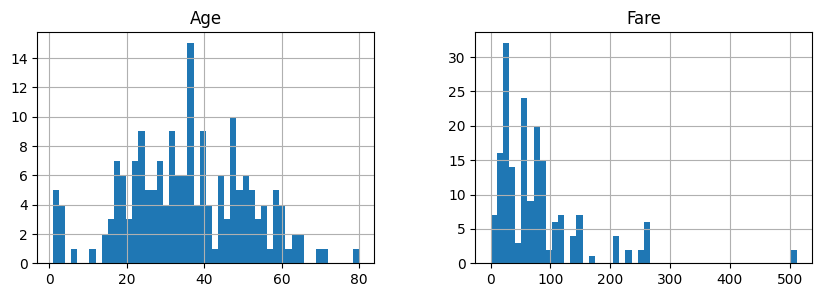

In [26]:
num_features.hist(figsize=(10, 3), bins = 50, xlabelsize=10, ylabelsize=10)

Можно также посмотреть на взаимное распределение всех признаков между собой

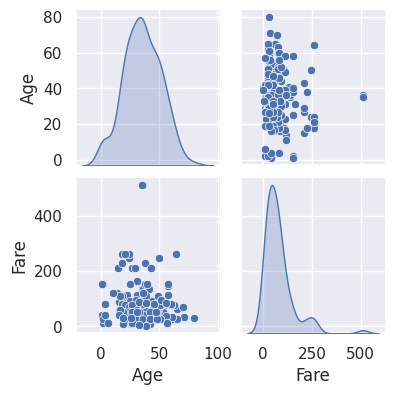

In [27]:
sns.set() #подключаем встроенные темы Seaborn
sns.pairplot(df[numerical_columns], height = 2, kind = 'scatter', diag_kind = 'kde') #взаимные графики на куче признаков
plt.show()

<Axes: >

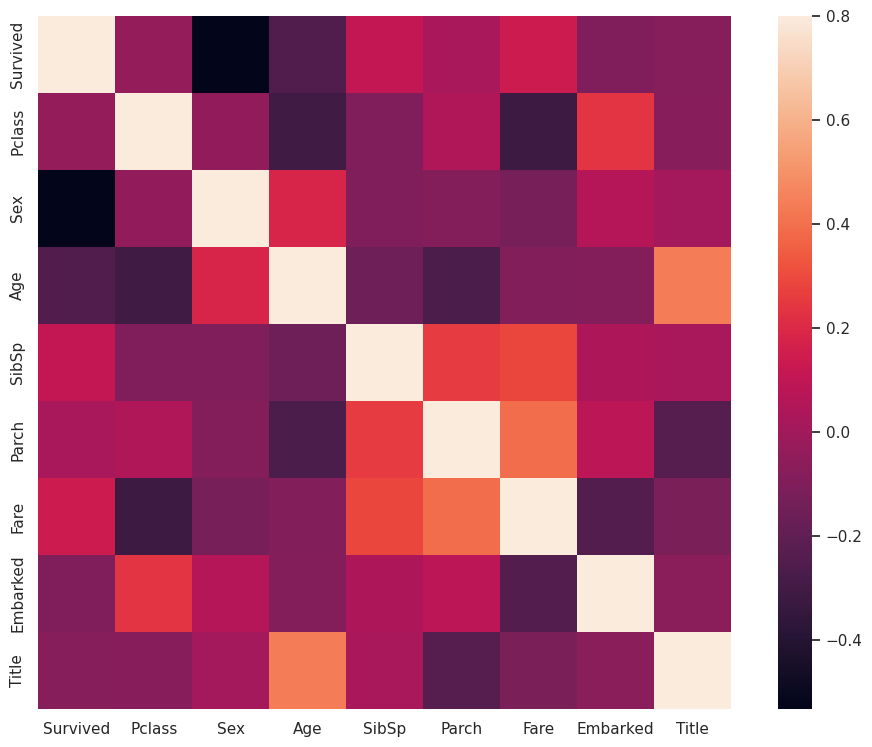

In [28]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corrmat, vmax = .8, square = True)

Сделаем картинку чуть понятнее и красивее:

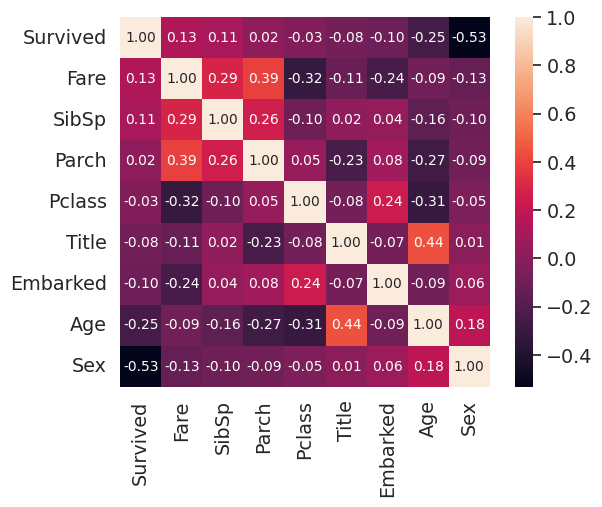

In [29]:
# correlation matrix
k = 10 # number of variables for heatmap
cols = corrmat.nlargest(k, 'Survived')['Survived'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

**Какие люди выживали чаще всего** в зависимости от:
1) класса обслужования
2) пола и возраста
3) стоимости билета

In [30]:
df['Survived'].value_counts()

Survived
1    123
0     60
Name: count, dtype: int64

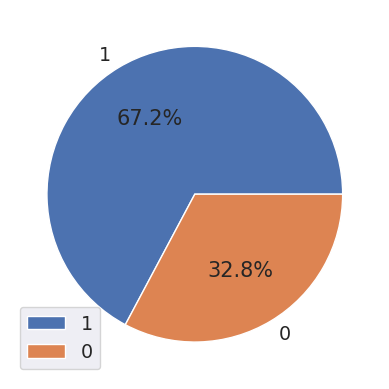

In [31]:
data = df['Survived'].value_counts()
plt.pie(data.values, labels = data.index, autopct = '%1.1f%%')
plt.legend()
plt.show()

Нарисуем для начала круговую диаграмму выживших в зависимости от **_класса_**

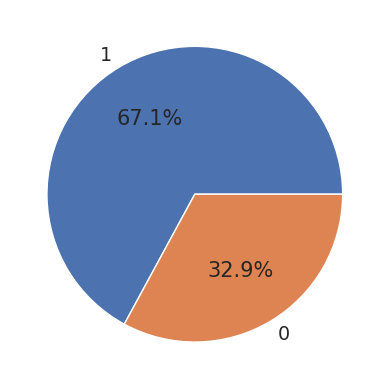

In [32]:
data1 = df.loc[(df.Pclass == 1)]['Survived'].value_counts()
plt.pie(data1.values, labels=data1.index, autopct = '%1.1f%%')
plt.show()

Теперь делаем для класса 2 и 3 тоже самое и объединяем их в один плот

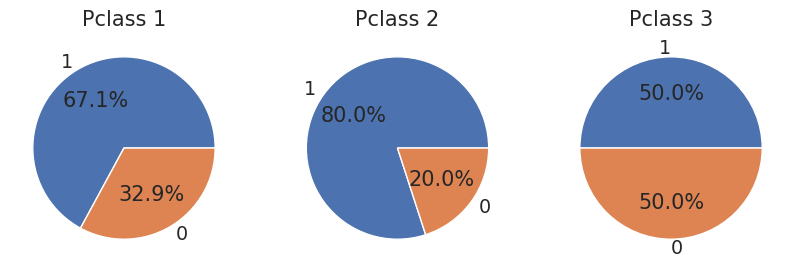

In [33]:
data2 = df.loc[(df.Pclass == 2)]['Survived'].value_counts()
data3 = df.loc[(df.Pclass == 3)]['Survived'].value_counts()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (10, 9)) #1 и 3 это 1 строка и 3 столбца
ax1.pie(data1.values, labels=data1.index, autopct = '%1.1f%%')
ax2.pie(data2.values, labels=data1.index, autopct = '%1.1f%%')
ax3.pie(data3.values, labels=data1.index, autopct = '%1.1f%%')

ax1.set_title("Pclass 1")
ax2.set_title("Pclass 2")
ax3.set_title("Pclass 3")
plt.show()

_Видим, что с самым низким классом выживали меньше всего_

Теперь нарисуем круговую диаграмму выживших в зависимости от **_возраста_**

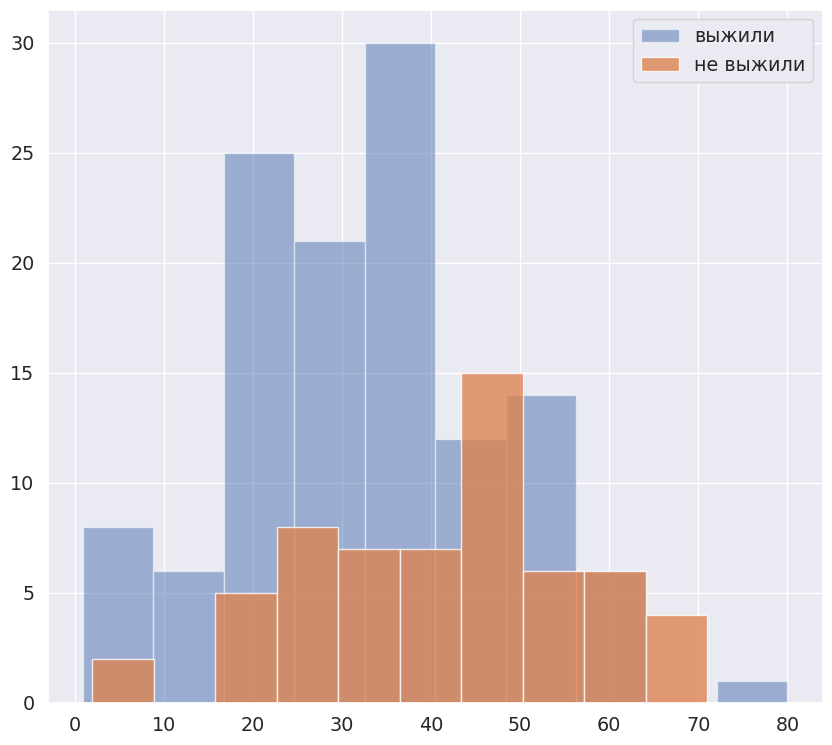

In [34]:
plt.figure(figsize=(10, 9))

plt.hist(df.loc[(df.Survived == 1)]['Age'], alpha = 0.5, label='выжили')
plt.hist(df.loc[(df.Survived == 0)]['Age'], alpha = 0.8, label='не выжили') #alpha - прозрачность

plt.legend()
plt.show()

In [35]:
data1 = df.loc[(df.Sex == 1)]['Survived'].value_counts()
data2 = df.loc[(df.Sex == 0)]['Survived'].value_counts()

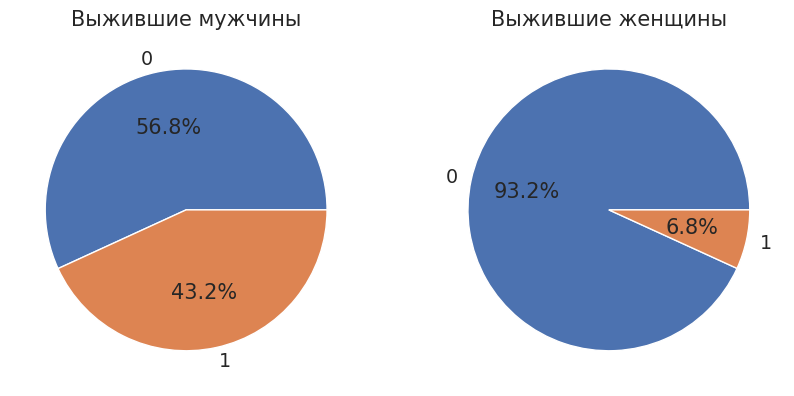

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 9))
ax1.pie(data1.values, labels=data1.index, autopct = '%1.1f%%')
ax2.pie(data2.values, labels=data1.index, autopct = '%1.1f%%')

ax1.set_title("Выжившие мужчины")
ax2.set_title("Выжившие женщины")

plt.show()

**_Заметим, что женщины выживали намного чаще_**

Посмотрим, есть ли влияние стоимости билета на выживаемость:

In [37]:
data1 = df.loc[(df.Survived == 1)]['Fare']
data2 = df.loc[(df.Survived == 0)]['Fare']

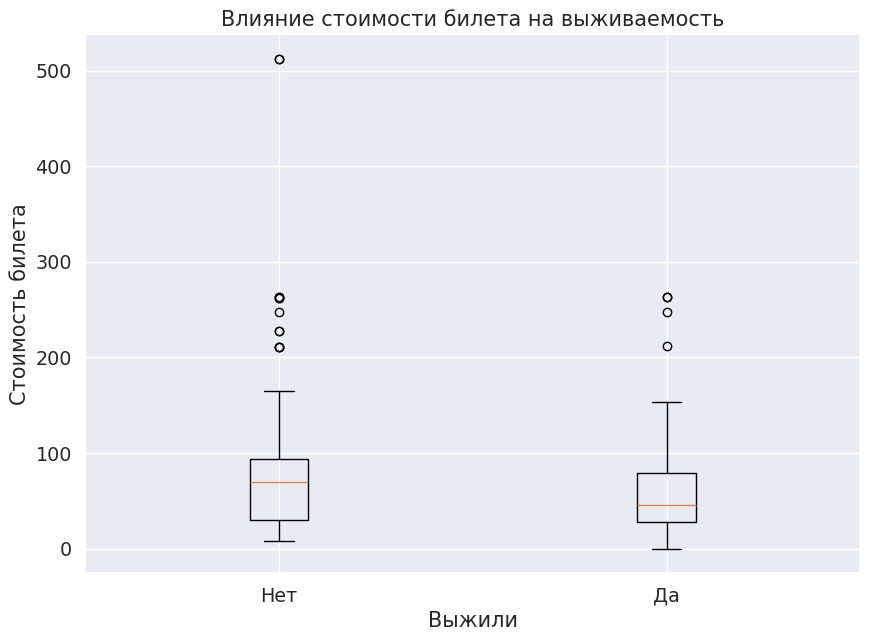

In [38]:
plt.figure(figsize = (10, 7))

plt.boxplot([data1, data2])

plt.title('Влияние стоимости билета на выживаемость')
plt.xlabel('Выжили')
plt.ylabel('Стоимость билета')
plt.xticks([1, 2], ['Нет', 'Да'])

plt.show()

Два боксплота для не выживших и выживших. Видим, что в обоих случаях есть выбросы. 

In [39]:
first_quartile = np.quantile(df['Fare'].values, q=0.25)
third_quartile = np.quantile(df['Fare'].values, q=0.75)
print(f'1ый квартиль = {first_quartile}')
print(f'3ий квартиль = {third_quartile}')

1ый квартиль = 29.7
3ий квартиль = 90.0


Посмотрим на боксплоты без выбросов

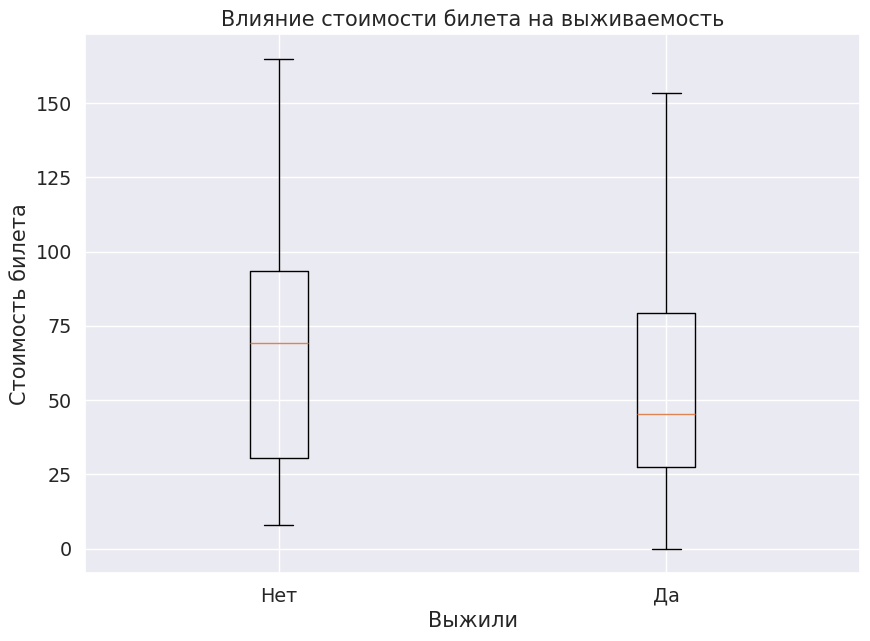

In [40]:
plt.figure(figsize = (10, 7))

plt.boxplot([data1, data2], showfliers = False)

plt.title('Влияние стоимости билета на выживаемость')
plt.xlabel('Выжили')
plt.ylabel('Стоимость билета')
plt.xticks([1, 2], ['Нет', 'Да'])

plt.show()

## Подготовка данных для обучения модели

разделяем на train/test


In [41]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
2,1,1,0,38.0,1,0,71.2833,0,3
4,1,1,0,35.0,1,0,53.1000,2,3
7,0,1,1,54.0,0,0,51.8625,2,2


In [42]:
x = df.drop(columns = ['Survived']).values #хотим только значения без названий столбцов
y = df['Survived'].values

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, shuffle = True)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train) #передаем не все данные, а только X_train - только данные для обучения, чтобы не было протечек информации
# Выход pca - numpy матрица, положим ее в новую переменную со всеми фичами
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
print('До масштабирования: ',x_train.mean(axis=0))
print('После масштабирования: ',x_train_scaled.mean(axis=0))

До масштабирования:  [ 1.23287671  0.50684932 35.73575342  0.45205479  0.48630137 76.10051438
  1.30821918  1.95205479]
После масштабирования:  [-7.60426729e-19 -7.45218195e-17  1.76419001e-16 -2.58545088e-17
 -2.58545088e-17 -4.01505313e-16  1.11022302e-16  5.47507245e-17]


In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(x_train)
# Выход pca - numpy матрица, положим ее в новую переменную со всеми фичами
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
print('До масштабирования: ',x_train.mean(axis=0))
print('После масштабирования: ',x_train_scaled.mean(axis=0))

До масштабирования:  [ 1.23287671  0.50684932 35.73575342  0.45205479  0.48630137 76.10051438
  1.30821918  1.95205479]
После масштабирования:  [0.11643836 0.50684932 0.44025991 0.15068493 0.12157534 0.14853831
 0.65410959 0.4880137 ]


## Что в итоге?

1. Очистка данных
2. Создание новых признаков
3. Удаление неинформативных столбцов
4. Анализ целевой переменной и признаков
5. Анализ влияния признаков на целевую переменную
6. Подготовка данных к обучению и валидации.